

# The Impact of Activation Functions on Training Dynamics
**Enhanced Analysis:** Weight Initialization, Regularization (L1/L2), Batch Normalization, Optimizers & Error Analysis

**Dataset:** MNIST | **Framework:** PyTorch | **Course:** SWE012 — Deep Learning with Python | **Weeks 2–5**

### T-Model Structure
- **DEPTH (Core):** Activation Functions — Sigmoid, Tanh, ReLU, LeakyReLU
- **BREADTH (Wk 2):** Bias-Variance Tradeoff, MLE, Capacity, Regularization Theory, SGD
- **BREADTH (Wk 3):** Softmax & Logits, BCE vs CCE, Depth vs Width, Backpropagation
- **BREADTH (Wk 4):** L1/L2 Regularization, Dropout, Label Smoothing
- **BREADTH (Wk 5):** He/Xavier Init, SGD/Momentum/Adam, Batch Normalization, LR Scheduler (bonus)

In [ ]:

## 0. Environment Setup


import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.ToTensor()
# Ham eğitim verisini indiriyoruz
full_train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# --- VALIDATION SET EKLEME ---
# MNIST Train set 60.000 resimden oluşur. 54.000 Train / 6.000 Val olarak bölüyoruz.
train_subset, val_subset = random_split(full_train_data, [54000, 6000])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_subset):,} | Val: {len(val_subset):,} | Test: {len(test_data):,}")

Device: cuda
Train: 54,000 | Val: 6,000 | Test: 10,000



## 1. Week 2 — ML Foundations: Bias-Variance, MLE & SGD

### Learning Algorithm = Task + Performance + Experience
A program learns from experience E w.r.t. task T and measure P, if P improves with E (Mitchell, 1997).

### Linear Regression
$$\hat{y} = w^T x, \quad w = (X^T X)^{-1} X^T y$$
$$\text{MSE}_{\text{test}} = \frac{1}{m} \sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2$$

### Capacity, Underfitting & Overfitting
- **Underfitting:** model too simple → high bias, low variance
- **Overfitting:** model too complex → low bias, high variance
- Controlled by model capacity (e.g. polynomial degree)

### Bias-Variance Tradeoff
$$\text{MSE} = \text{Bias}(\hat{\theta})^2 + \text{Var}(\hat{\theta})$$
Bias = $E[\hat{\theta}] - \theta$ (systematic error), Variance = fluctuation across samples, SE = $\sigma/\sqrt{m}$

### MLE (Maximum Likelihood Estimation)
$$\theta_{\text{ML}} = \arg\max_\theta \sum_i \log p(x^{(i)}; \theta)$$
**Key insight:** MLE + Gaussian noise = MSE minimization. MSE is not arbitrary — it follows from a probabilistic model.

### Bayesian Perspective
$$p(\theta|\text{data}) \propto p(\text{data}|\theta) \cdot p(\theta)$$
MAP + Gaussian prior $\Leftrightarrow$ L2 weight decay. MAP + Laplace prior $\Leftrightarrow$ L1 regularization.

### Point Estimation
An estimator $\hat{\theta} = g(x^{(1)}, ..., x^{(m)})$ is a function of data, hence a random variable.
- **Bias:** $\text{bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$. Unbiased if bias = 0.
- **Variance:** $\text{Var}(\hat{\theta})$ measures fluctuation. SE = $\sigma/\sqrt{m}$.
- **Consistency:** $\hat{\theta} \to \theta_{true}$ as $m \to \infty$.

### Hyperparameters & Validation
Hyperparameters (lr, $\lambda$, capacity) are NOT learned during training — tuned on a **validation set**.
- **Data split:** Train (learns params) / Validation (tunes hyperparams) / Test (final eval — used once!)
- **K-Fold Cross-Validation:** Split data into K folds, each fold serves as test once. Essential for small datasets.

### No Free Lunch Theorem
No single algorithm is universally best across all distributions. We must design for our specific problem.

### SGD
$$\theta \leftarrow \theta - \varepsilon \nabla_\theta J(\theta)$$
Minibatch instead of full batch → noise helps escape local minima. Train/Val/Test split — test set used once.


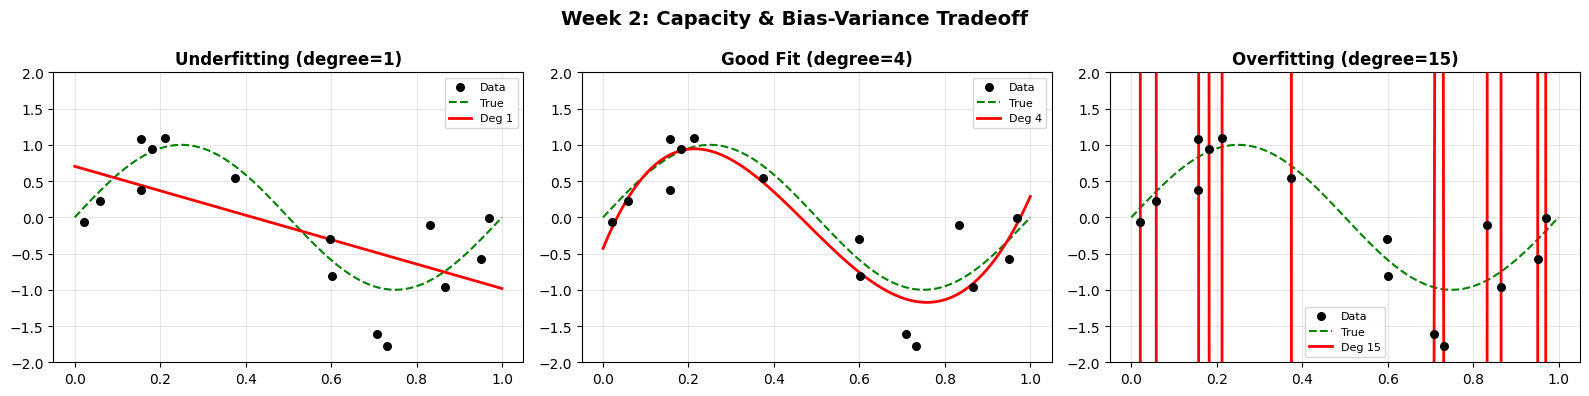


--- MLE = MSE under Gaussian noise ---
p(y|x) = N(y; ŷ, σ²) → maximizing log-likelihood ⟺ minimizing Σ||ŷ−y||²


In [ ]:
# Bias-Variance Tradeoff: Polynomial Regression Demo
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)
x_true = np.linspace(0, 1, 100)
y_true = np.sin(2 * np.pi * x_true)
x_train = np.random.uniform(0, 1, 15)
y_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, 0.3, 15)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, deg, title in zip(axes, [1, 4, 15],
    ["Underfitting (degree=1)", "Good Fit (degree=4)", "Overfitting (degree=15)"]):
    poly = PolynomialFeatures(deg)
    X_poly = poly.fit_transform(x_train.reshape(-1, 1))
    model = LinearRegression().fit(X_poly, y_train)
    y_pred = model.predict(poly.transform(x_true.reshape(-1, 1)))
    ax.scatter(x_train, y_train, color="black", s=30, zorder=5, label="Data")
    ax.plot(x_true, y_true, "g--", lw=1.5, label="True")
    ax.plot(x_true, y_pred, "r-", lw=2, label=f"Deg {deg}")
    ax.set_title(title, fontweight="bold"); ax.set_ylim(-2, 2)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("Week 2: Capacity & Bias-Variance Tradeoff", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("0_bias_variance.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n--- MLE = MSE under Gaussian noise ---")
print("p(y|x) = N(y; ŷ, σ²) → maximizing log-likelihood ⟺ minimizing Σ||ŷ−y||²")

## 2. Week 3 — Softmax, Logits & Cross-Entropy

### Logits → Softmax → Probabilities
$$\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$
Logits are raw scores from the final layer. Softmax converts them to probabilities in $(0,1)$ summing to 1.

### Cross-Entropy Loss
**BCE** (2-class): $-[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ → use with Sigmoid

**CCE** (multi-class): $-\sum_i y_i \log\hat{y}_i$ → use with Softmax. Only the true class term survives (one-hot y).

| Output | Loss | Use Case |
|---|---|---|
| Sigmoid | BCE | Binary classification |
| Softmax | CCE | Multi-class |
| Linear | MSE | Regression |

**Key:** Gradient is large when prediction is wrong → fast learning. Never apply softmax before `nn.CrossEntropyLoss`.

### Why Depth Beats Width
Each layer folds input space → after $L$ layers: $2^L$ decision regions with linear parameters.

### Backpropagation = Chain Rule + Memoization
$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial z^{(L)}} \cdot \prod_k \sigma'(z^{(k)}) \cdot W^{(k+1)}$$
All gradients in $O(\text{forward pass time})$ via stored activations. PyTorch: `loss.backward()`.

In [ ]:
# Softmax & Cross-Entropy Demo
z = torch.tensor([2.0, 1.0, 0.1])
probs = torch.softmax(z, dim=0)
print("Logits: ", z.numpy())
print("Softmax:", probs.numpy(), "  Sum:", probs.sum().item())

# Manual vs PyTorch CCE
y_true = torch.tensor([0])
logits = torch.tensor([[2.0, 1.0, 0.1]])
manual_cce = -torch.log(probs[0])
pytorch_cce = nn.CrossEntropyLoss()(logits, y_true)
print(f"\nManual CCE:  {manual_cce.item():.4f}")
print(f"PyTorch CCE: {pytorch_cce.item():.4f}")

# BCE Demo
y_bin = torch.tensor([1.0]); pred = torch.tensor([0.8])
bce = nn.BCELoss()(pred, y_bin)
print(f"\nBCE Loss (y=1, ŷ=0.8): {bce.item():.4f}")

Logits:  [2.  1.  0.1]
Softmax: [0.6590012  0.24243298 0.09856589]   Sum: 1.0000001192092896

Manual CCE:  0.4170
PyTorch CCE: 0.4170

BCE Loss (y=1, ŷ=0.8): 0.2231


## 3. Model Architecture: DeepMLP with Optional BatchNorm

`784 → 128 → 128 → 128 → 128 → 10` (4 hidden layers)

With `use_batchnorm=True`: **Linear → BatchNorm → Activation → Dropout**

BatchNorm normalizes pre-activations to mean=0, var=1, placing inputs in the non-saturating region of Sigmoid/Tanh.

In [ ]:
class DeepMLP(nn.Module):
    def __init__(self, activation_fn, use_dropout=True, use_batchnorm=False):
        super().__init__()
        self.flatten = nn.Flatten()
        self.use_batchnorm = use_batchnorm
        self.layers = nn.ModuleList([nn.Linear(28*28, 128)] + [nn.Linear(128, 128) for _ in range(3)])
        if use_batchnorm:
            self.batchnorms = nn.ModuleList([nn.BatchNorm1d(128) for _ in range(4)])
        self.activation = activation_fn
        self.dropout = nn.Dropout(0.2) if use_dropout else nn.Identity()
        self.out = nn.Linear(128, 10)

    def forward(self, x, store_activations=False):
        x = self.flatten(x)
        self._acts = []
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if self.use_batchnorm: x = self.batchnorms[i](x)
            x = self.activation(x)
            if store_activations: self._acts.append(x.detach().cpu())
            if i < 3: x = self.dropout(x)
        return self.out(x)

## 4. Weight Initialization (Week 5)

### The Signal Flow Problem
- **Symmetry Breaking:** If all weights start identical, every neuron computes the same thing → must be random.
- **Vanishing Gradients:** Weights too small → signal shrinks exponentially through layers.
- **Exploding Gradients:** Weights too large → signal grows exponentially → unstable updates.

**Xavier:** $\text{Var}(w) = 2/(n_{in}+n_{out})$ — for Sigmoid/Tanh

**He (Kaiming):** $\text{Var}(w) = 2/n_{in}$ — ReLU zeroes ~50% of activations, ×2 compensates

In [ ]:
def apply_kaiming_init(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None: nn.init.zeros_(m.bias)
    return model

def apply_xavier_init(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
    return model

print("Init functions: kaiming_normal_ (ReLU), xavier_normal_ (Sigmoid/Tanh)")

Init functions: kaiming_normal_ (ReLU), xavier_normal_ (Sigmoid/Tanh)


## 5. Training Infrastructure

### Dead ReLU Problem
Neuron with $z < 0$ for all inputs → ReLU output = 0, gradient = 0, permanently dead.
**LeakyReLU:** $0.01z$ for $z < 0$ → always non-zero gradient.

### L1 Regularization (applied only to weights, not biases)
$$\Omega = \sum |w_i|, \quad \nabla = \alpha \cdot \text{sign}(w)$$
Constant force → drives weights to exact zero (sparsity). L2 shrinks proportionally (never reaches zero).

In [ ]:
EPOCHS = 15

def compute_dead_neurons(model, loader, n_batches=3):
    model.eval()
    sums = None
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_batches: break
            x = x.to(device)
            _ = model(x, store_activations=True)
            if sums is None: sums = [torch.zeros(a.shape[1]) for a in model._acts]
            for j, a in enumerate(model._acts): sums[j] += a.abs().sum(dim=0)
    dead = [(s == 0).sum().item() for s in sums]
    return sum(dead) / sum(s.numel() for s in sums) * 100

def train_model(name, activation, optimizer_type="sgd", lr=0.01,
                weight_decay=0.0, l1_lambda=0.0, label_smoothing=0.0,
                use_dropout=True, use_batchnorm=False, init_type="default",
                use_scheduler=False):
    model = DeepMLP(activation, use_dropout, use_batchnorm).to(device)
    if init_type == "kaiming": apply_kaiming_init(model)
    elif init_type == "xavier": apply_xavier_init(model)

    # Optimizörler
    if optimizer_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_type == "nesterov":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    elif optimizer_type == "adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5) if use_scheduler else None
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    # DÜZELTME: val_losses listesi eklendi
    losses, val_losses, val_accs, grad_norms, lr_history = [], [], [], [], []

    for epoch in tqdm(range(EPOCHS), desc=name):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            # L1 on weights only (not biases)
            if l1_lambda > 0:
                loss += l1_lambda * sum(p.abs().sum() for n, p in model.named_parameters() if 'weight' in n)
            loss.backward()
            grad_norms.append(sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None))
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_loader))
        lr_history.append(scheduler.get_last_lr()[0] if scheduler else lr)
        if scheduler: scheduler.step()

        # DÜZELTME: Doğrulama işlemi sırasında Val Loss hesaplaması eklendi
        model.eval()
        val_loss = 0
        correct = total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)

                # Validation Loss hesaplama
                v_loss = loss_fn(outputs, y)
                val_loss += v_loss.item()

                correct += (outputs.argmax(1) == y).sum().item()
                total += y.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * correct / total)

    # Eğitim bittikten sonra test seti sadece 1 KERE çalıştırılır.
    model.eval()
    test_correct = test_total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            test_correct += (model(x).argmax(1) == y).sum().item()
            test_total += y.size(0)
    final_test_acc = 100 * test_correct / test_total

    # DÜZELTME: val_loss sonucu dictionary'ye eklendi
    return {"loss": losses, "val_loss": val_losses, "acc": val_accs, "test_acc": final_test_acc,
            "grad": grad_norms, "dead": compute_dead_neurons(model, train_loader),
            "lr_history": lr_history, "model": model}

print(f"Training infrastructure ready. Epochs={EPOCHS}")

Training infrastructure ready. Epochs=15



## 6. Experiments


In [ ]:
results = {}
def run(name, **kw): results[name] = train_model(name, **kw)

# Phase 1: Activation Functions
run("ReLU",      activation=nn.ReLU())
run("Sigmoid",   activation=nn.Sigmoid())
run("Tanh",      activation=nn.Tanh())
run("LeakyReLU", activation=nn.LeakyReLU(0.01))

# Wk4: Regularization
run("ReLU_NoDropout",      activation=nn.ReLU(), use_dropout=False)
run("ReLU_L1",             activation=nn.ReLU(), l1_lambda=1e-4)
run("ReLU_L2",             activation=nn.ReLU(), weight_decay=1e-4)
run("ReLU_LabelSmoothing", activation=nn.ReLU(), label_smoothing=0.1)

# Wk5: Optimizers (YENİ OPTİMİZÖRLER EKLENDİ)
run("SGD",      activation=nn.ReLU(), optimizer_type="sgd")
run("Momentum", activation=nn.ReLU(), optimizer_type="momentum")
run("Nesterov", activation=nn.ReLU(), optimizer_type="nesterov")
run("AdaGrad",  activation=nn.ReLU(), optimizer_type="adagrad")
run("RMSProp",  activation=nn.ReLU(), optimizer_type="rmsprop")
run("Adam",     activation=nn.ReLU(), optimizer_type="adam")

# Wk5: Weight Initialization
run("Sigmoid_Xavier",  activation=nn.Sigmoid(), init_type="xavier")
run("Sigmoid_Kaiming", activation=nn.Sigmoid(), init_type="kaiming")
run("ReLU_He",         activation=nn.ReLU(),    init_type="kaiming")

# Phase 2: BatchNorm
run("ReLU_BN",    activation=nn.ReLU(),    use_batchnorm=True)
run("Sigmoid_BN", activation=nn.Sigmoid(), use_batchnorm=True, init_type="xavier")

# Bonus: LR Scheduler
run("Adam_Scheduler", activation=nn.ReLU(), optimizer_type="adam", use_scheduler=True)

print(f"\nAll {len(results)} experiments complete.")

Adam_Scheduler: 100%|██████████| 15/15 [02:11<00:00,  8.77s/it]



All 20 experiments complete.


## 7. Results Summary

In [ ]:
rows = []
for name, r in results.items():
    rows.append({"Model": name, "Final Val Acc": round(r["acc"][-1], 2), "Test Acc": round(r["test_acc"], 2),
                 "Best Val Acc": round(max(r["acc"]), 2), "Dead %": round(r["dead"], 2)})
df = pd.DataFrame(rows)
print(df.to_markdown(index=False))

| Model               |   Final Val Acc |   Test Acc |   Best Val Acc |   Dead % |
|:--------------------|----------------:|-----------:|---------------:|---------:|
| ReLU                |           93.33 |      93.98 |          93.33 |     2.54 |
| Sigmoid             |           10.93 |      10.28 |          11.1  |     0    |
| Tanh                |           91.48 |      92.07 |          91.48 |     0    |
| LeakyReLU           |           92.77 |      93.19 |          92.77 |     0    |
| ReLU_NoDropout      |           92.18 |      92.82 |          92.18 |     9.18 |
| ReLU_L1             |           92.85 |      93.27 |          92.85 |     3.52 |
| ReLU_L2             |           92.85 |      93.11 |          92.85 |     4.69 |
| ReLU_LabelSmoothing |           93.98 |      94.83 |          93.98 |     1.95 |
| SGD                 |           93.5  |      94.02 |          93.5  |     3.52 |
| Momentum            |           97.48 |      97.67 |          97.48 |     1.17 |
| Ne

## 8. Phase 1: Activation Function Comparison

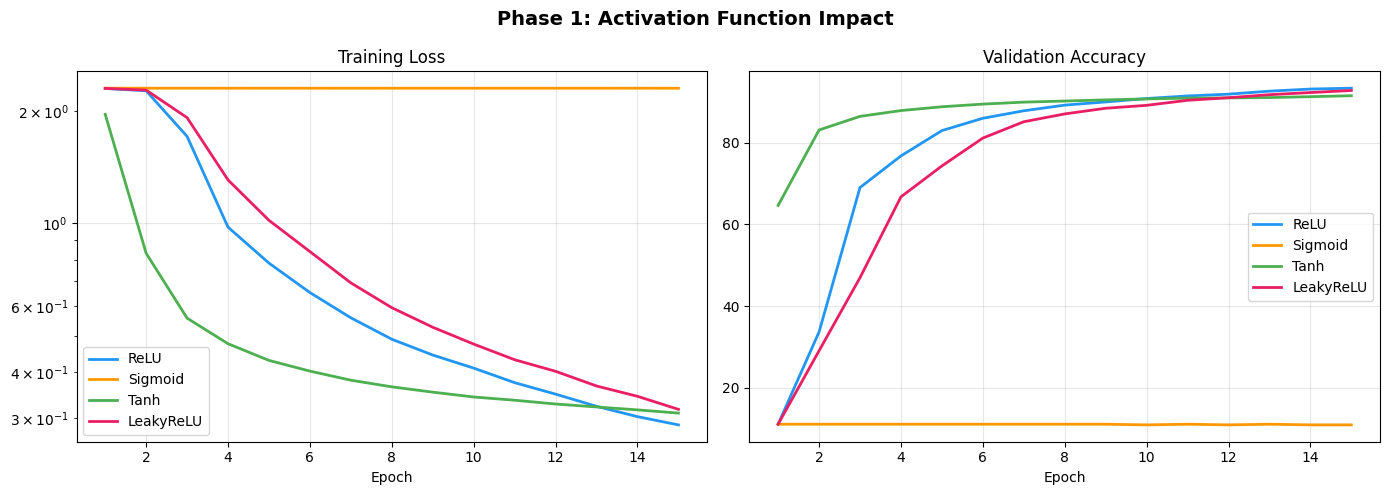

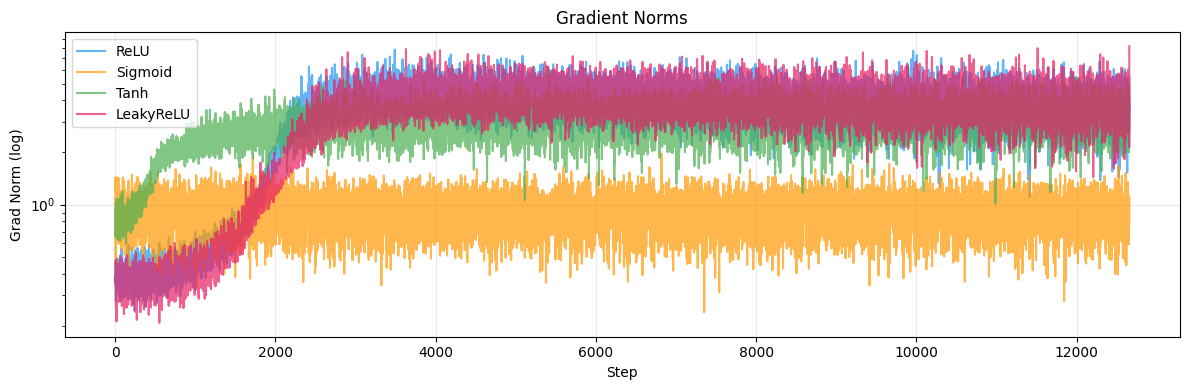

/tmp/ipykernel_3228/4160402296.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a1.set_title("Dead Neuron %"); a1.set_xticklabels(names,rotation=45,ha="right")


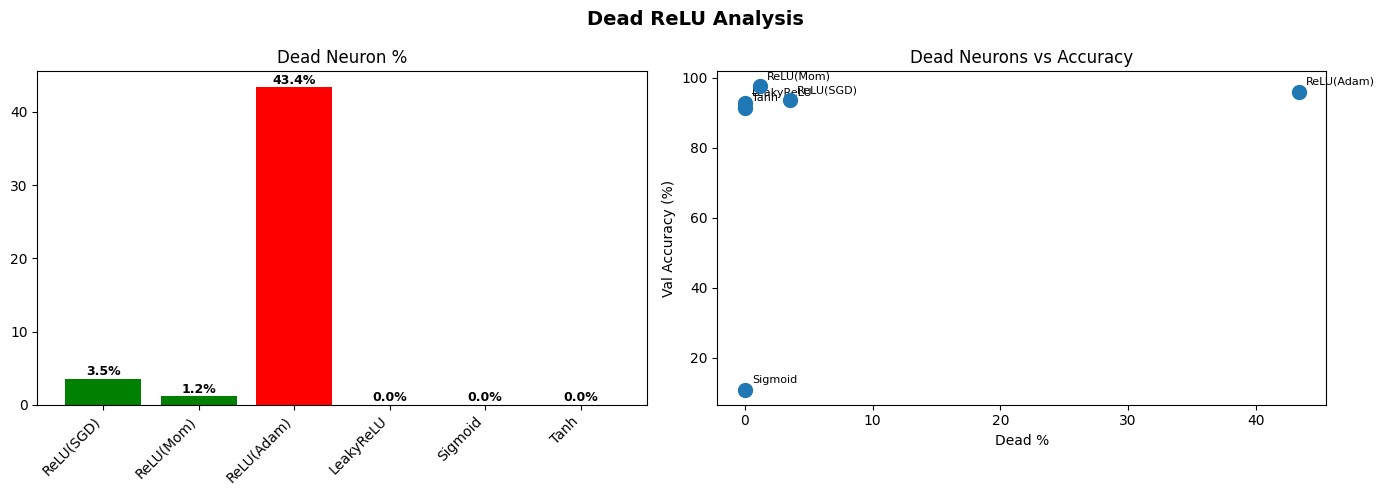

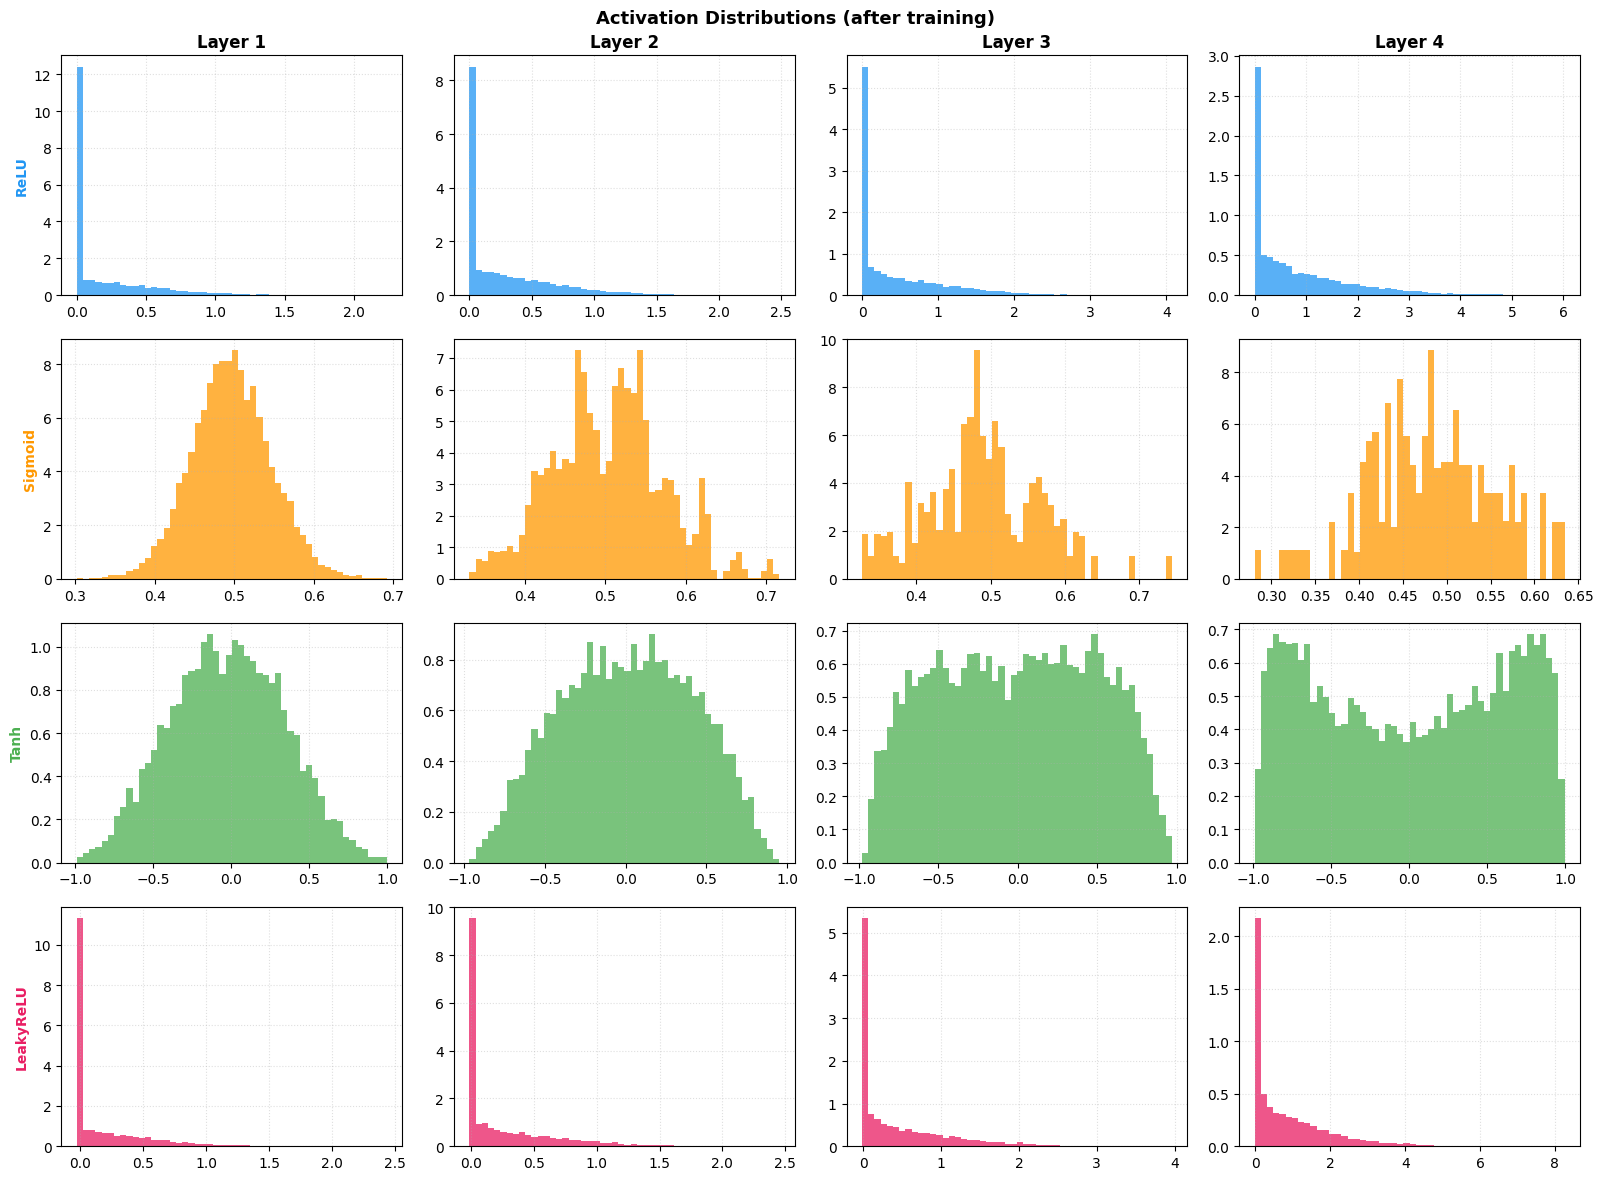

In [ ]:
ep = range(1, EPOCHS+1)
p1 = ["ReLU","Sigmoid","Tanh","LeakyReLU"]
clr = {"ReLU":"#2196F3","Sigmoid":"#FF9800","Tanh":"#4CAF50","LeakyReLU":"#E91E63"}

fig, (a1,a2) = plt.subplots(1,2,figsize=(14,5))
for n in p1:
    a1.plot(ep, results[n]["loss"], label=n, color=clr[n], lw=2)
    a2.plot(ep, results[n]["acc"],  label=n, color=clr[n], lw=2)
a1.set_yscale("log"); a1.set_title("Training Loss"); a1.legend(); a1.grid(True, alpha=0.3)
a2.set_title("Validation Accuracy"); a2.legend(); a2.grid(True, alpha=0.3)
for a in [a1,a2]: a.set_xlabel("Epoch")
plt.suptitle("Phase 1: Activation Function Impact", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("1_loss_accuracy.png", dpi=150, bbox_inches="tight"); plt.show()

"""### Gradient Norms"""

fig, ax = plt.subplots(figsize=(12,4))
for n in p1: ax.plot(results[n]["grad"], label=n, color=clr[n], alpha=0.7)
ax.set_yscale("log"); ax.set_title("Gradient Norms"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel("Step"); ax.set_ylabel("Grad Norm (log)")
plt.tight_layout(); plt.savefig("2_gradient_norms.png", dpi=150, bbox_inches="tight"); plt.show()

"""### Dead Neuron Analysis"""

dead_data = {"ReLU(SGD)":results["SGD"]["dead"], "ReLU(Mom)":results["Momentum"]["dead"],
    "ReLU(Adam)":results["Adam"]["dead"], "LeakyReLU":results["LeakyReLU"]["dead"],
    "Sigmoid":results["Sigmoid"]["dead"], "Tanh":results["Tanh"]["dead"]}

fig,(a1,a2) = plt.subplots(1,2,figsize=(14,5))
names=list(dead_data.keys()); vals=list(dead_data.values())
colors=['red' if v>20 else 'orange' if v>5 else 'green' for v in vals]
bars=a1.bar(names,vals,color=colors)
a1.set_title("Dead Neuron %"); a1.set_xticklabels(names,rotation=45,ha="right")
for b,v in zip(bars,vals): a1.text(b.get_x()+b.get_width()/2,b.get_height()+0.5,f"{v:.1f}%",ha="center",fontsize=9,fontweight="bold")

acc_v=[results[k]["acc"][-1] for k in ["SGD","Momentum","Adam","LeakyReLU","Sigmoid","Tanh"]]
dead_v=[results[k]["dead"] for k in ["SGD","Momentum","Adam","LeakyReLU","Sigmoid","Tanh"]]
lbls=["ReLU(SGD)","ReLU(Mom)","ReLU(Adam)","LeakyReLU","Sigmoid","Tanh"]
a2.scatter(dead_v,acc_v,s=100,zorder=5)
for l,x,y in zip(lbls,dead_v,acc_v): a2.annotate(l,(x,y),textcoords="offset points",xytext=(5,5),fontsize=8)
a2.set_xlabel("Dead %"); a2.set_ylabel("Val Accuracy (%)"); a2.set_title("Dead Neurons vs Accuracy")
plt.suptitle("Dead ReLU Analysis", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("3_dead_neurons.png", dpi=150, bbox_inches="tight"); plt.show()

"""### Activation Distributions"""

sample, _ = next(iter(val_loader))
sample = sample.to(device)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for row, n in enumerate(["ReLU","Sigmoid","Tanh","LeakyReLU"]):
    m = results[n]["model"]; m.eval()
    with torch.no_grad(): m(sample, store_activations=True)
    for col in range(4):
        ax = axes[row][col]; v = m._acts[col].numpy().flatten()
        ax.hist(v, bins=50, color=clr[n], alpha=0.75, density=True)
        ax.grid(True, ls=":", alpha=0.4)
        if row==0: ax.set_title(f"Layer {col+1}", fontweight="bold")
        if col==0: ax.set_ylabel(n, fontweight="bold", color=clr[n])
plt.suptitle("Activation Distributions (after training)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("4_distributions.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Week 4: Regularization — L1/L2, Dropout, Label Smoothing

**L2:** $\tilde{J} = J + \frac{\alpha}{2}\|w\|_2^2$ → $w \leftarrow (1-\varepsilon\alpha)w - \varepsilon\nabla J$ (rubber band, Gaussian prior)

**L1:** $\Omega = \|w\|_1$ → $\nabla = \alpha\cdot\text{sign}(w)$ (constant force → exact zero, Laplace prior, feature selection)

**Dropout:** $\tilde{h} = \mu \odot h$, $\mu \sim \text{Bernoulli}(p)$ → $2^n$ ensemble. Inverted: scale by $1/p$ at train.

**Norm Penalties as Constrained Optimization:**
Penalty approach (minimize $J + \alpha\Omega$) $\Leftrightarrow$ constraint approach (minimize $J$ s.t. $\Omega \leq k$).
L2 constraint region = ball (circle). L1 = diamond (corners on axes → sparse solutions).

**Semi-Supervised & Self-Supervised Learning:**
Semi-supervised uses both labeled $(x,y)$ and unlabeled $(x)$ data. Self-supervised creates artificial tasks from data itself (e.g. BERT masked LM, GPT next-token). Modern pipeline: pre-train on unlabeled data to learn $P(x)$, fine-tune for $P(y|x)$.

**Adversarial Training (FGSM):**
$\tilde{x} = x + \varepsilon \cdot \text{sign}(\nabla_x J(\theta, x, y))$ — nudge each pixel to maximally increase loss.
Training on adversarial examples forces smoother decision boundaries → acts as regularization.

**Label Smoothing:** correct = $1-\varepsilon$, wrong = $\varepsilon/(k-1)$ → prevents overconfident predictions.

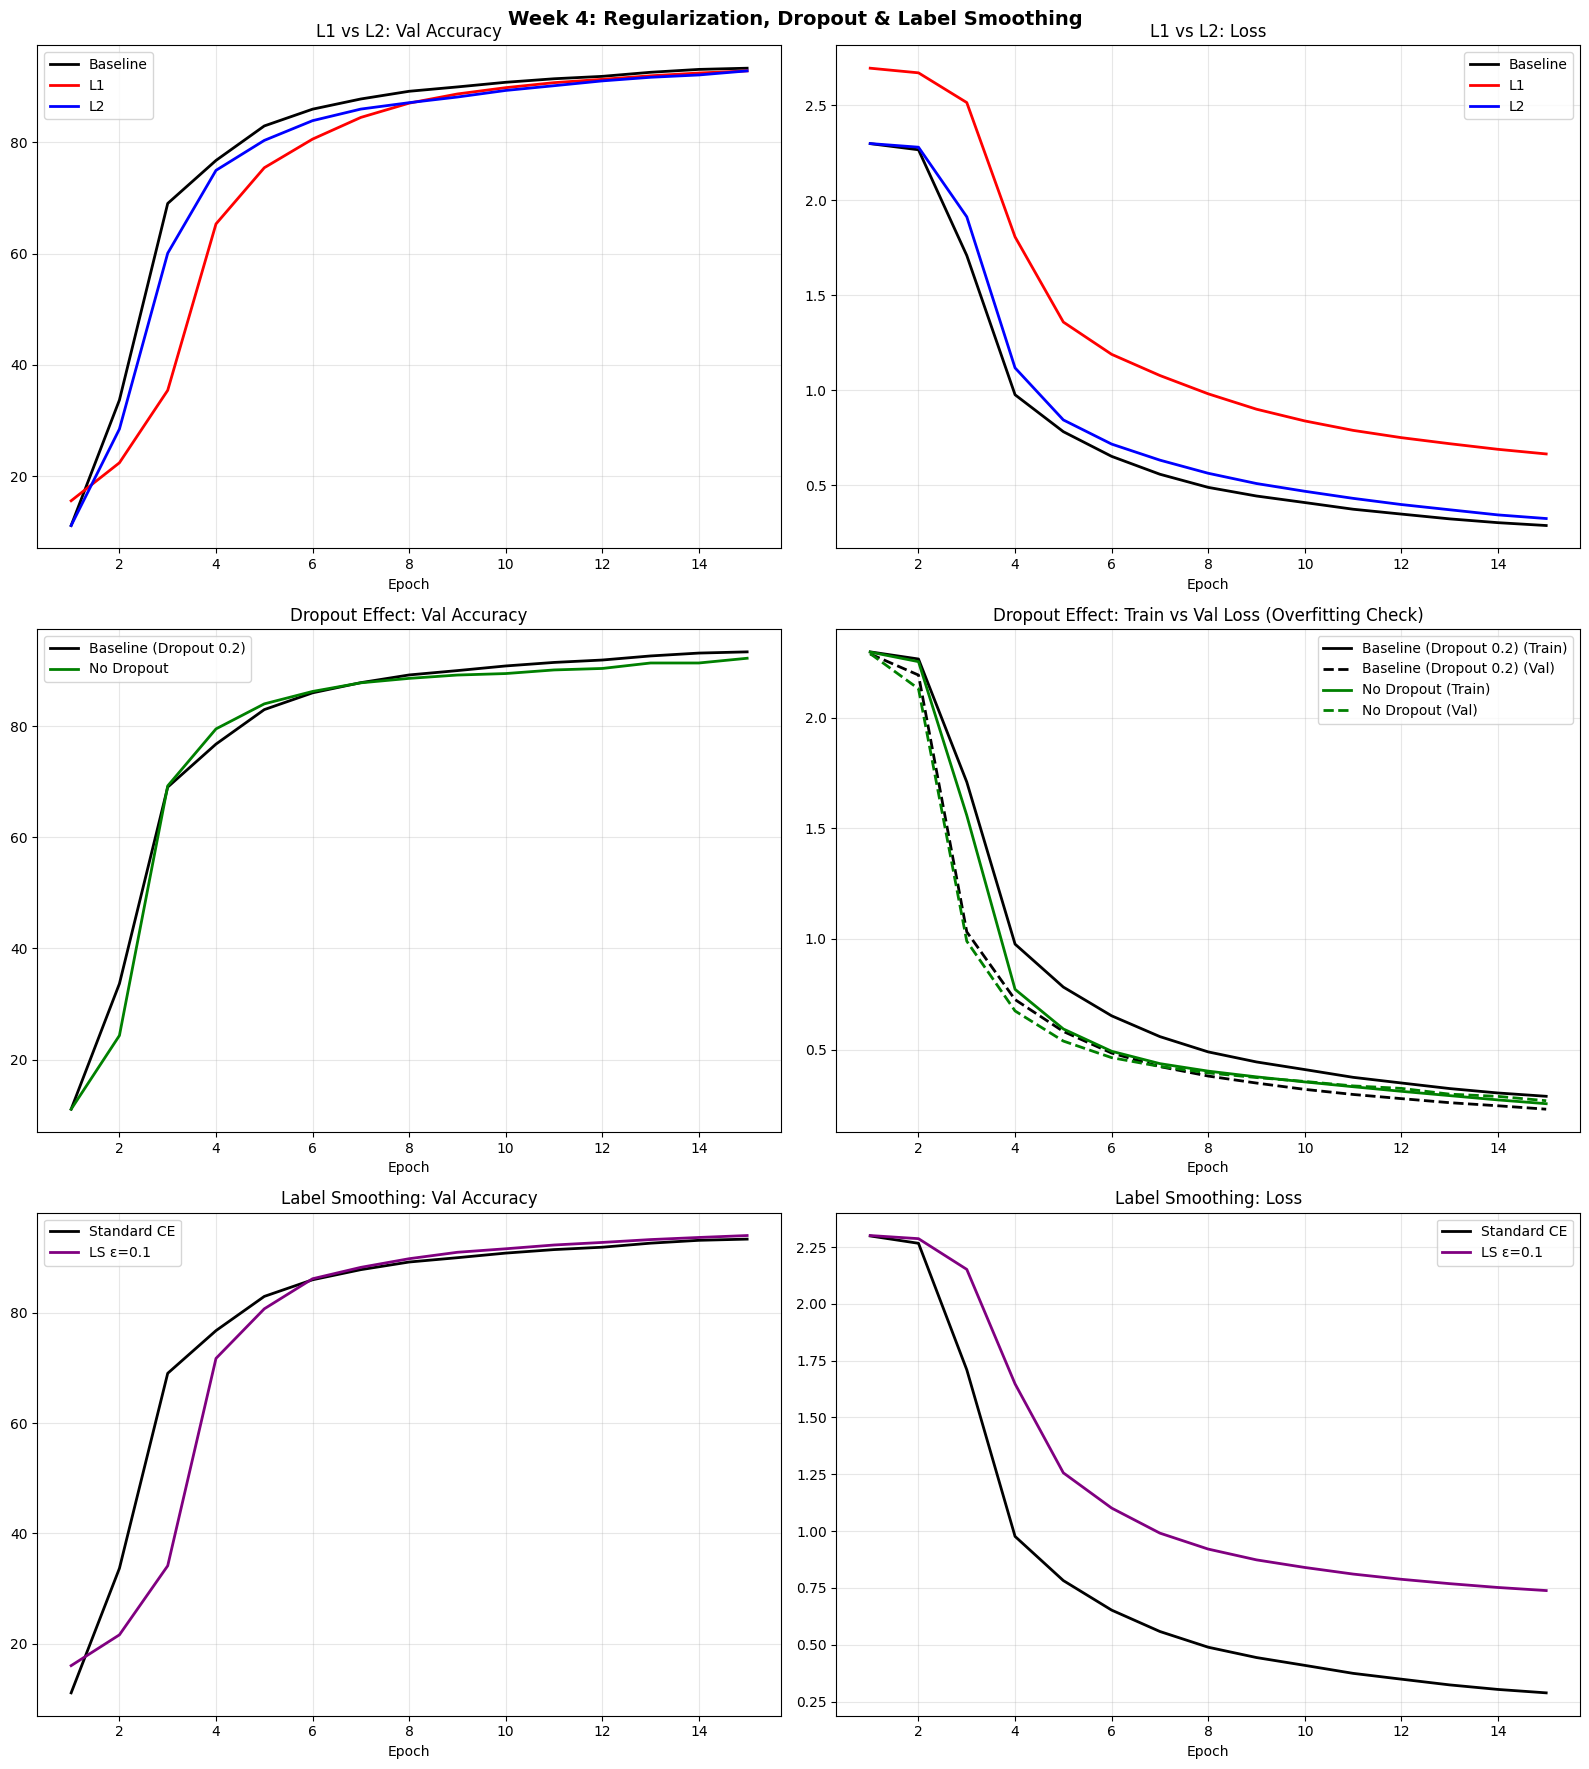

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# L1 vs L2: Accuracy
for n,l,c in [("ReLU","Baseline","black"),("ReLU_L1","L1","red"),("ReLU_L2","L2","blue")]:
    axes[0,0].plot(ep, results[n]["acc"], label=l, color=c, lw=2)
axes[0,0].set_title("L1 vs L2: Val Accuracy"); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# L1 vs L2: Loss
for n,l,c in [("ReLU","Baseline","black"),("ReLU_L1","L1","red"),("ReLU_L2","L2","blue")]:
    axes[0,1].plot(ep, results[n]["loss"], label=l, color=c, lw=2)
axes[0,1].set_title("L1 vs L2: Loss"); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# DÜZELTME: Overfitting Görselleştirmesi - Train Loss vs Val Loss
for n,l,c in [("ReLU","Baseline (Dropout 0.2)","black"),("ReLU_NoDropout","No Dropout","green")]:
    axes[1,0].plot(ep, results[n]["acc"], label=l, color=c, lw=2)
    # Düz çizgi Train Loss, Kesikli çizgi Val Loss
    axes[1,1].plot(ep, results[n]["loss"], label=f"{l} (Train)", color=c, lw=2, linestyle='-')
    axes[1,1].plot(ep, results[n]["val_loss"], label=f"{l} (Val)", color=c, lw=2, linestyle='--')

axes[1,0].set_title("Dropout Effect: Val Accuracy"); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
axes[1,1].set_title("Dropout Effect: Train vs Val Loss (Overfitting Check)"); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# Label Smoothing: Accuracy
for n,l,c in [("ReLU","Standard CE","black"),("ReLU_LabelSmoothing","LS ε=0.1","purple")]:
    axes[2,0].plot(ep, results[n]["acc"], label=l, color=c, lw=2)
axes[2,0].set_title("Label Smoothing: Val Accuracy"); axes[2,0].legend(); axes[2,0].grid(True, alpha=0.3)

# Label Smoothing: Loss
for n,l,c in [("ReLU","Standard CE","black"),("ReLU_LabelSmoothing","LS ε=0.1","purple")]:
    axes[2,1].plot(ep, results[n]["loss"], label=l, color=c, lw=2)
axes[2,1].set_title("Label Smoothing: Loss"); axes[2,1].legend(); axes[2,1].grid(True, alpha=0.3)

for a in axes.flat: a.set_xlabel("Epoch")
plt.suptitle("Week 4: Regularization, Dropout & Label Smoothing", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("5_regularization.png", dpi=150, bbox_inches="tight"); plt.show()

## 10. Week 5: Weight Initialization

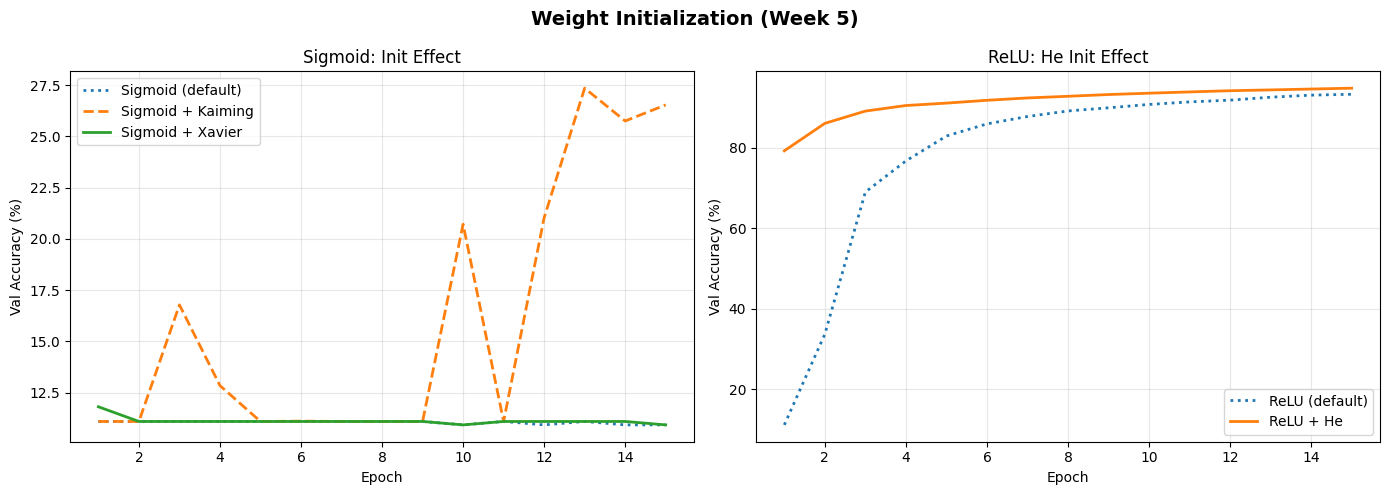

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, results["Sigmoid"]["acc"], label="Sigmoid (default)", ls=":", lw=2)
axes[0].plot(ep, results["Sigmoid_Kaiming"]["acc"], label="Sigmoid + Kaiming", ls="--", lw=2)
axes[0].plot(ep, results["Sigmoid_Xavier"]["acc"], label="Sigmoid + Xavier", ls="-", lw=2)
axes[0].set_title("Sigmoid: Init Effect"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, results["ReLU"]["acc"], label="ReLU (default)", ls=":", lw=2)
axes[1].plot(ep, results["ReLU_He"]["acc"], label="ReLU + He", ls="-", lw=2)
axes[1].set_title("ReLU: He Init Effect"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

for a in axes: a.set_xlabel("Epoch"); a.set_ylabel("Val Accuracy (%)")
plt.suptitle("Weight Initialization (Week 5)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("6_initialization.png", dpi=150, bbox_inches="tight"); plt.show()

## 11. Week 5: Batch Normalization

Addresses **Internal Covariate Shift** — each layer's input distribution changes as earlier layers update.

**Steps:** (1) $\mu = \text{mean}(x)$ (2) $\sigma^2 = \text{var}(x)$ (3) $\hat{x} = (x-\mu)/\sqrt{\sigma^2+\varepsilon}$ (4) $y = \gamma\hat{x} + \beta$

Learnable $\gamma, \beta$ let network undo normalization if needed. Layer Norm (across features) is standard for Transformers.

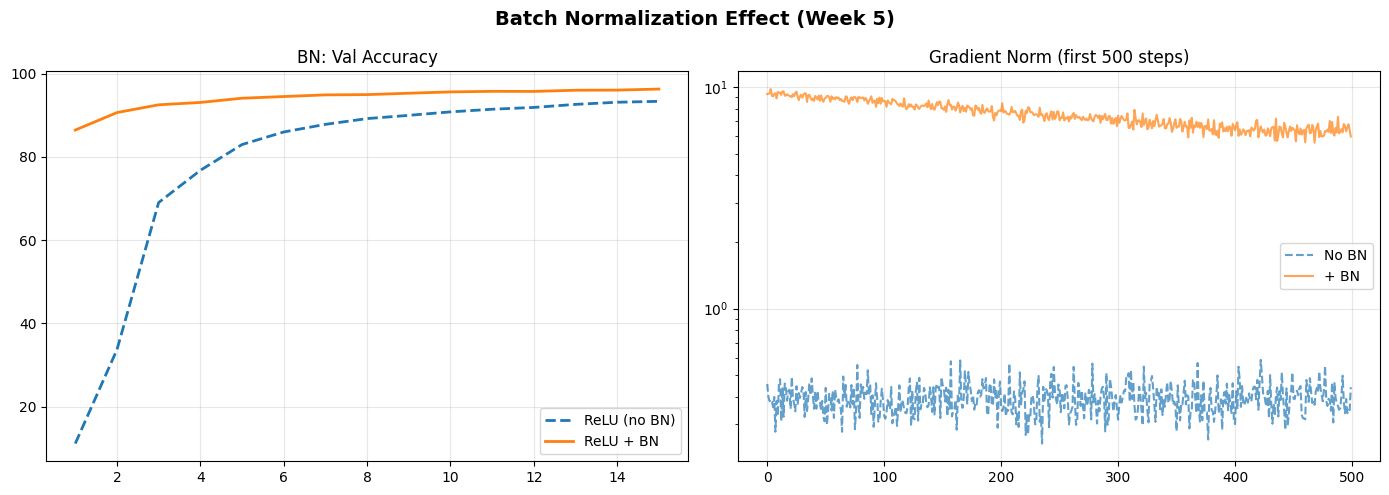

ReLU: 93.33% | ReLU+BN: 96.28% | Sigmoid+BN: 89.58%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, results["ReLU"]["acc"], label="ReLU (no BN)", ls="--", lw=2)
axes[0].plot(ep, results["ReLU_BN"]["acc"], label="ReLU + BN", ls="-", lw=2)
axes[0].set_title("BN: Val Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

n=500
axes[1].plot(results["ReLU"]["grad"][:n], label="No BN", ls="--", alpha=0.7)
axes[1].plot(results["ReLU_BN"]["grad"][:n], label="+ BN", ls="-", alpha=0.7)
axes[1].set_yscale("log"); axes[1].set_title("Gradient Norm (first 500 steps)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Batch Normalization Effect (Week 5)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("7_batchnorm.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"ReLU: {results['ReLU']['acc'][-1]:.2f}% | ReLU+BN: {results['ReLU_BN']['acc'][-1]:.2f}% | Sigmoid+BN: {results['Sigmoid_BN']['acc'][-1]:.2f}%")

## 12. Week 5: Optimizer Comparison

| Optimizer | Rule | Property |
|---|---|---|
| SGD | $w \leftarrow w - \varepsilon\nabla J$ | Simple, oscillates |
| Momentum | $v \leftarrow \beta v - \varepsilon\nabla J$ | Bounces cancel, pushes accumulate |
| Nesterov | Gradient at $w+\beta v$ ("look ahead") | Brakes before overshooting |
| AdaGrad | $r \leftarrow r+g^2$; $w \leftarrow w-\varepsilon/\sqrt{r}\cdot g$ | Per-param rates. Fatal: $r$ grows forever → lr→0 |
| RMSProp | $r \leftarrow \rho r+(1-\rho)g^2$ | Fixes AdaGrad: exponential moving avg |
| Adam | 1st + 2nd moment + bias corr. | Industry standard |

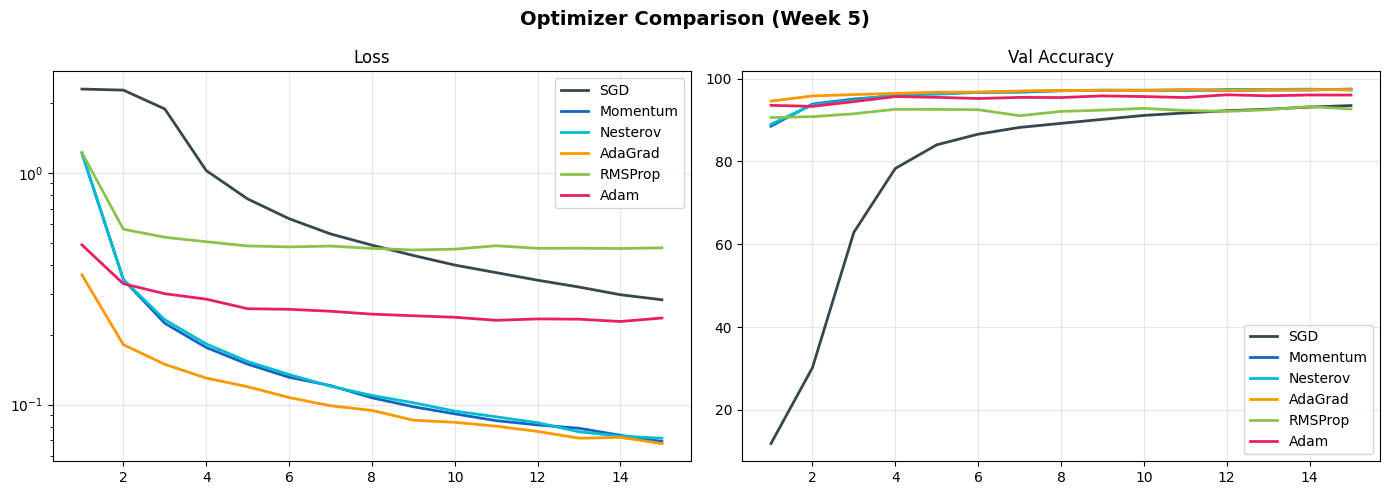

In [ ]:
fig, (a1,a2) = plt.subplots(1,2,figsize=(14,5))
# Tüm optimizörler
for n,c in [("SGD","#37474F"), ("Momentum","#1565C0"), ("Nesterov","#00BCD4"),
            ("AdaGrad","#FF9800"), ("RMSProp","#8BC34A"), ("Adam","#E91E63")]:
    a1.plot(ep, results[n]["loss"], label=n, color=c, lw=2)
    a2.plot(ep, results[n]["acc"],  label=n, color=c, lw=2)
a1.set_yscale("log"); a1.set_title("Loss"); a1.legend(); a1.grid(True, alpha=0.3)
a2.set_title("Val Accuracy"); a2.legend(); a2.grid(True, alpha=0.3)
plt.suptitle("Optimizer Comparison (Week 5)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("8_optimizers.png", dpi=150, bbox_inches="tight"); plt.show()

## 13. Bonus: LR Scheduler (StepLR)

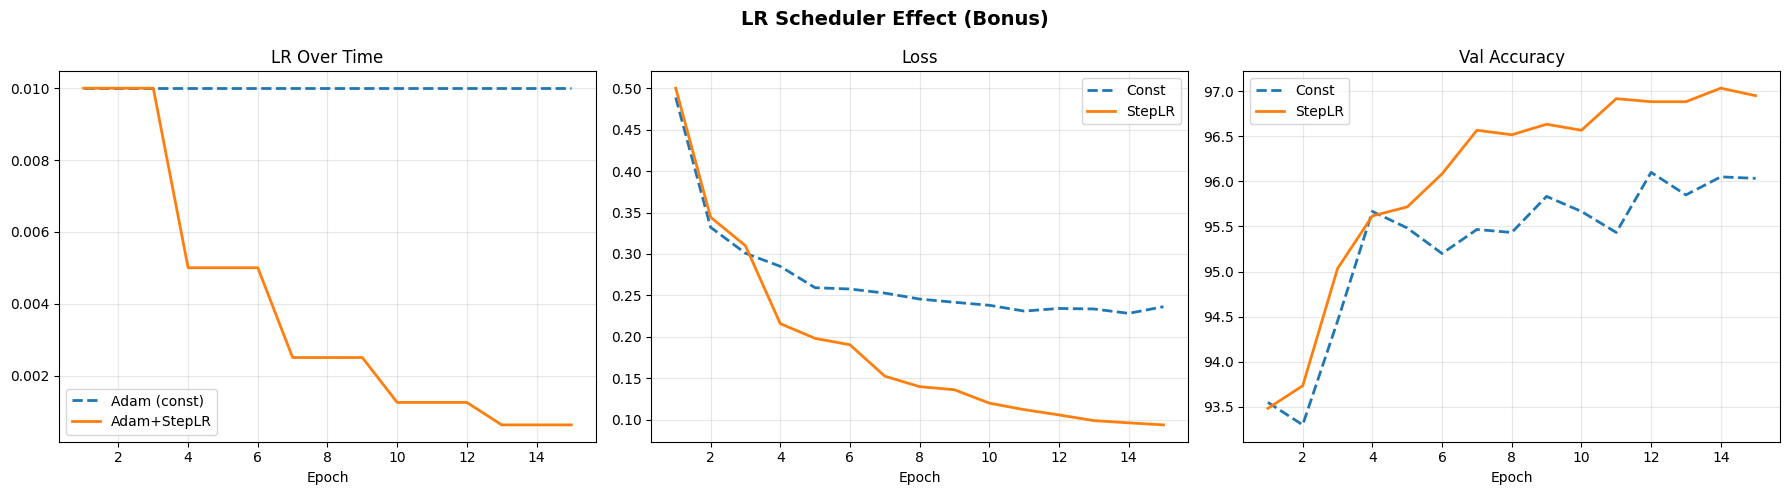

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ep, results["Adam"]["lr_history"], label="Adam (const)", ls="--", lw=2)
axes[0].plot(ep, results["Adam_Scheduler"]["lr_history"], label="Adam+StepLR", ls="-", lw=2)
axes[0].set_title("LR Over Time"); axes[0].legend()
axes[1].plot(ep, results["Adam"]["loss"], label="Const", ls="--", lw=2)
axes[1].plot(ep, results["Adam_Scheduler"]["loss"], label="StepLR", ls="-", lw=2)
axes[1].set_title("Loss"); axes[1].legend()
axes[2].plot(ep, results["Adam"]["acc"], label="Const", ls="--", lw=2)
axes[2].plot(ep, results["Adam_Scheduler"]["acc"], label="StepLR", ls="-", lw=2)
axes[2].set_title("Val Accuracy"); axes[2].legend()
for a in axes: a.grid(True, alpha=0.3); a.set_xlabel("Epoch")
plt.suptitle("LR Scheduler Effect (Bonus)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("9_lr_scheduler.png", dpi=150, bbox_inches="tight"); plt.show()

## 14. Error Analysis: Confusion Matrix

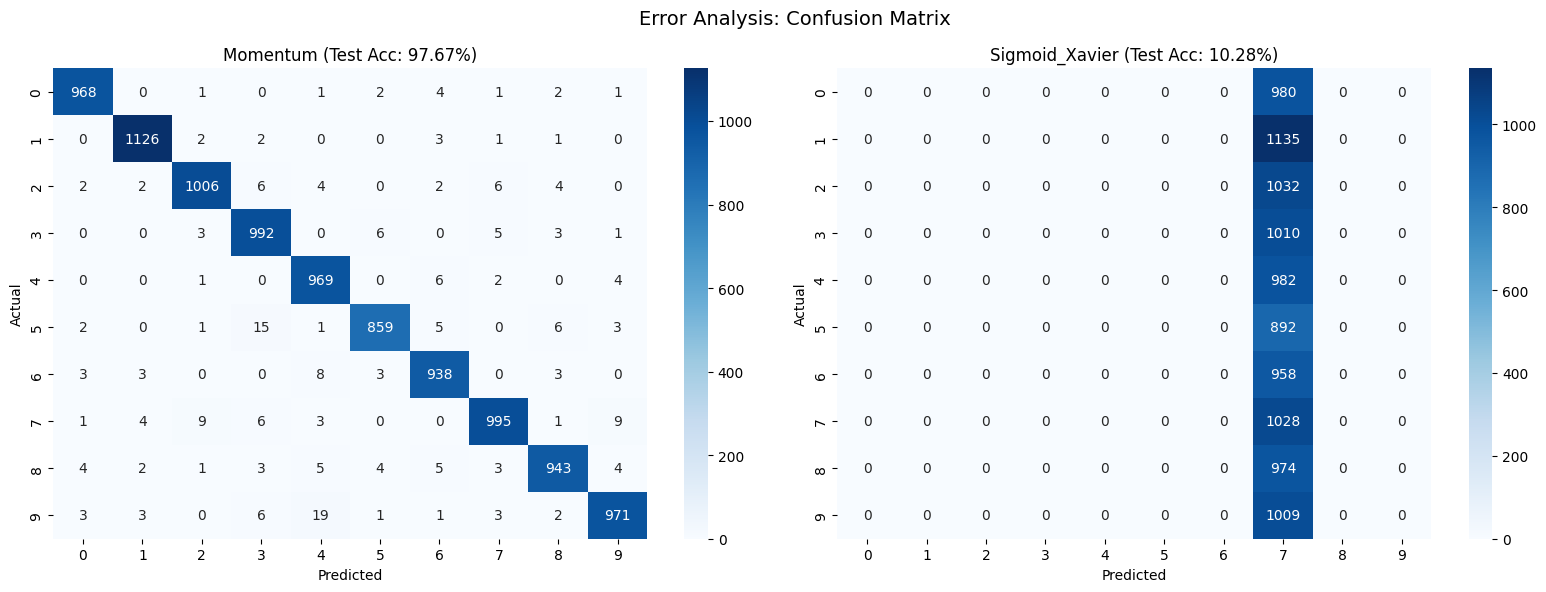

In [ ]:
def get_preds(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(labels), np.array(preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for (name, ax) in [("Momentum", axes[0]), ("Sigmoid_Xavier", axes[1])]:
    yt, yp = get_preds(results[name]["model"], test_loader)
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10), ax=ax)
    ax.set_title(f"{name} (Test Acc: {results[name]['test_acc']:.2f}%)"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Error Analysis: Confusion Matrix", fontsize=14)
plt.tight_layout(); plt.savefig("10_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

## 15. Theoretical Visualization: Activation Functions & Derivatives

$\sigma'(x) = \sigma(x)(1-\sigma(x))$, max = **0.25**. After 4 layers: $0.25^4 = 0.004$ → Layer 0 gets 250× less signal.

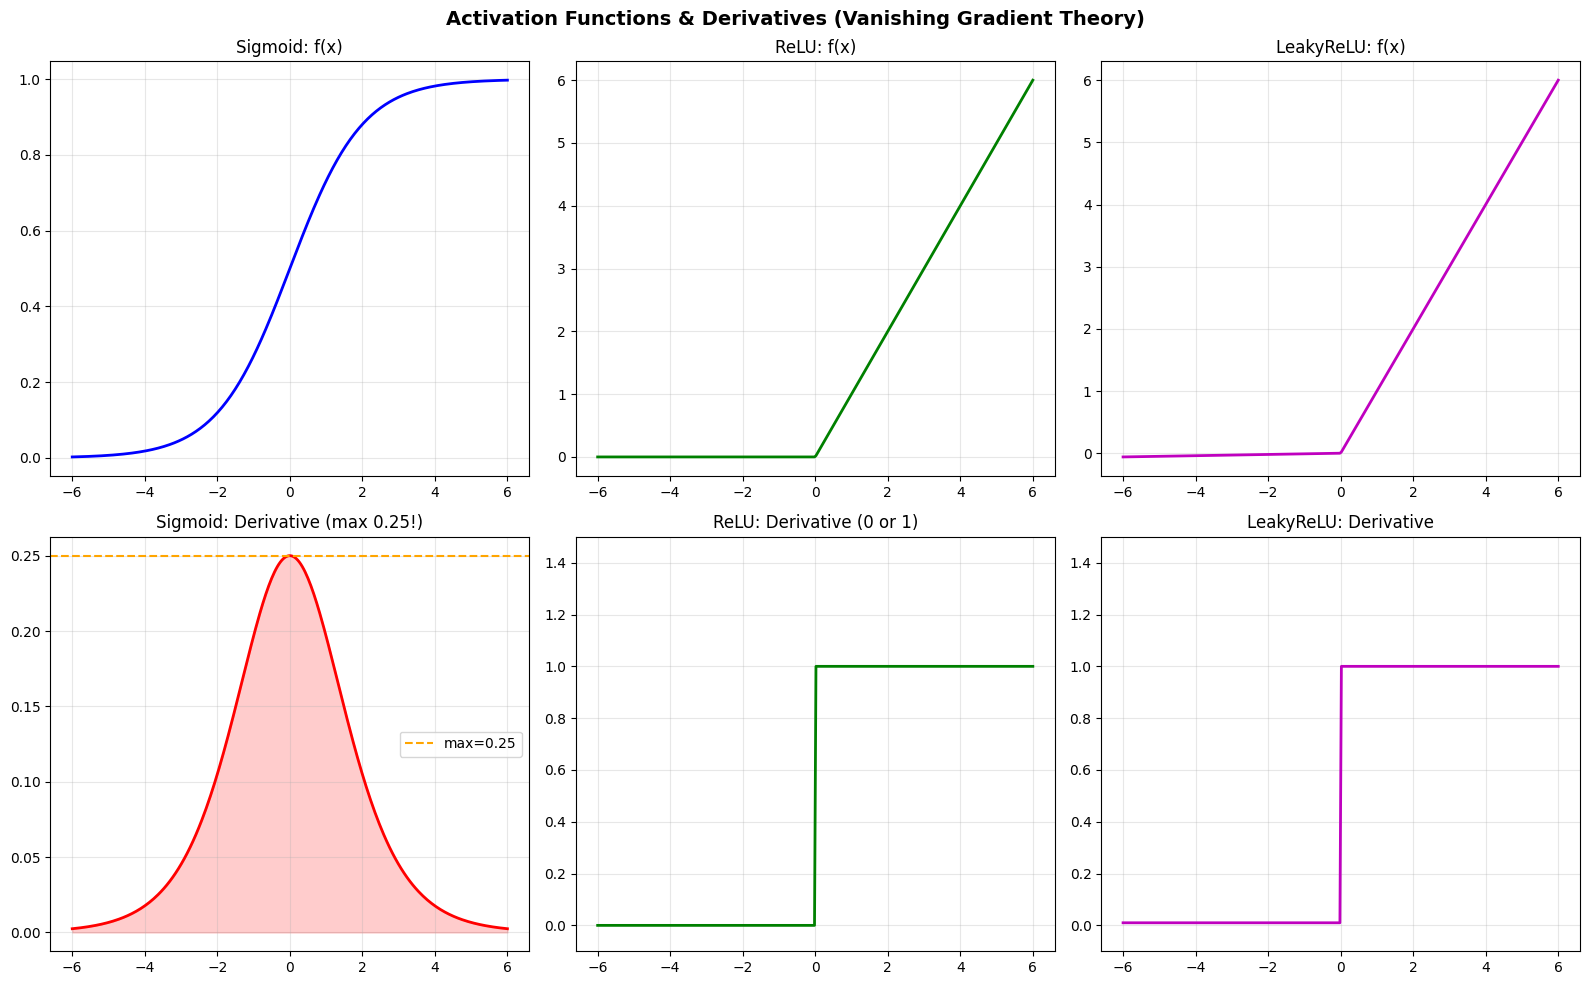


Sigmoid gradient decay through layers:
  Layer 1: 0.250000
  Layer 2: 0.062500
  Layer 3: 0.015625
  Layer 4: 0.003906
  Layer 5: 0.000977
  Layer 6: 0.000244
  Layer 7: 0.000061
  Layer 8: 0.000015


In [ ]:
x = np.linspace(-6, 6, 300)
sig = 1/(1+np.exp(-x)); ds = sig*(1-sig)
relu = np.maximum(0,x); dr = (x>0).astype(float)
lk = np.where(x>0,x,0.01*x); dl = np.where(x>0,1.0,0.01)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes[0,0].plot(x,sig,'b',lw=2); axes[0,0].set_title("Sigmoid: f(x)"); axes[0,0].grid(True,alpha=0.3)
axes[1,0].plot(x,ds,'r',lw=2); axes[1,0].axhline(0.25,color='orange',ls='--',label='max=0.25')
axes[1,0].fill_between(x,ds,alpha=0.2,color='red'); axes[1,0].set_title("Sigmoid: Derivative (max 0.25!)")
axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)
axes[0,1].plot(x,relu,'g',lw=2); axes[0,1].set_title("ReLU: f(x)"); axes[0,1].grid(True,alpha=0.3)
axes[1,1].plot(x,dr,'g',lw=2); axes[1,1].set_title("ReLU: Derivative (0 or 1)"); axes[1,1].set_ylim(-0.1,1.5); axes[1,1].grid(True,alpha=0.3)
axes[0,2].plot(x,lk,'m',lw=2); axes[0,2].set_title("LeakyReLU: f(x)"); axes[0,2].grid(True,alpha=0.3)
axes[1,2].plot(x,dl,'m',lw=2); axes[1,2].set_title("LeakyReLU: Derivative"); axes[1,2].set_ylim(-0.1,1.5); axes[1,2].grid(True,alpha=0.3)
plt.suptitle("Activation Functions & Derivatives (Vanishing Gradient Theory)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("11_theory.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nSigmoid gradient decay through layers:")
g=1.0
for l in range(1,9): g*=0.25; print(f"  Layer {l}: {g:.6f}")